In [1]:
!pip install -q kaggle
from google.colab import files
files.upload()   # select the kaggle.json you just downloaded
!mkdir -p ~/.kaggle && cp kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json

Saving kaggle.json to kaggle.json


In [2]:
!kaggle datasets download -d pallav23/icg-spacenet-sandox-yolo
!unzip -q icg-spacenet-sandox-yolo.zip -d /content/
print("Done.")

Dataset URL: https://www.kaggle.com/datasets/pallav23/icg-spacenet-sandox-yolo
License(s): CC-BY-SA-4.0
100% 950M/950M [01:00<00:00, 16.4MB/s]

Done.


In [3]:
import glob
print("Images:", len(glob.glob('/content/**/*.png', recursive=True)))
print("Labels:", len(glob.glob('/content/**/*.txt', recursive=True)))

Images: 1148
Labels: 1148


In [4]:
import os, glob

imgs = sorted(glob.glob('/content/**/images/*.png', recursive=True))
lbls = sorted(glob.glob('/content/**/labels/*.txt', recursive=True))
print(f"Images: {len(imgs)}, Labels: {len(lbls)}")

# peek at one label file
with open(lbls[0]) as f:
    print("\nSample label:", lbls[0])
    print(f.read())

Images: 1148, Labels: 1148

Sample label: /content/spacenet_buildings_yolo/labels/AOI_3_Paris_img10.txt



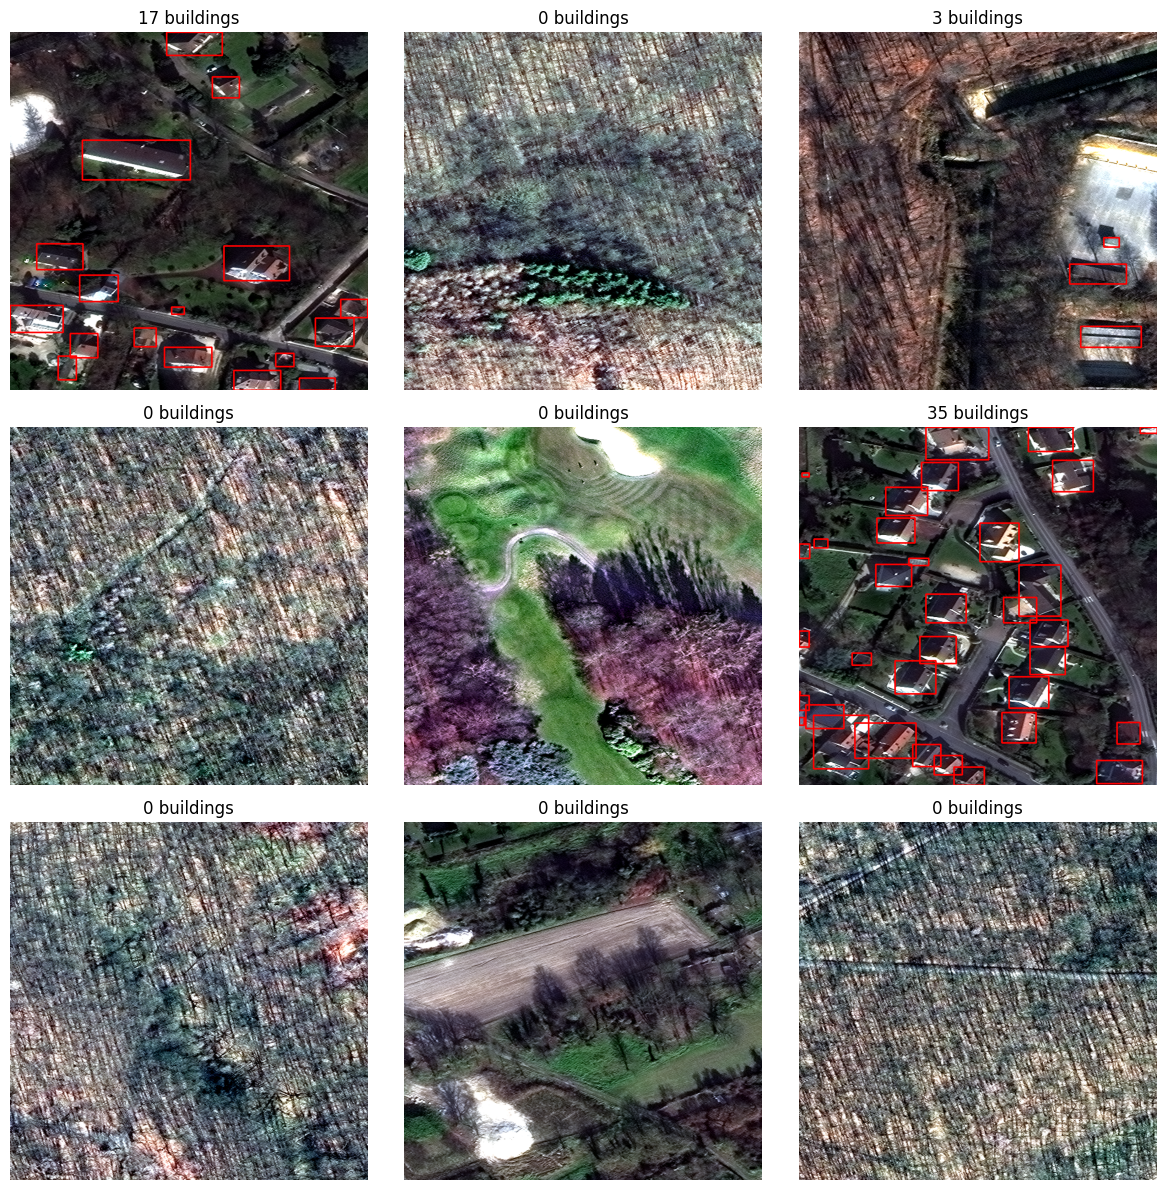

In [5]:
import random, cv2, matplotlib.pyplot as plt
import numpy as np

random.seed(42)
sample = random.sample(imgs, 9)

fig, axes = plt.subplots(3, 3, figsize=(12, 12))
for ax, img_path in zip(axes.flat, sample):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    lbl_path = img_path.replace('images', 'labels').replace('.png', '.txt')
    building_count = 0
    if os.path.exists(lbl_path):
        with open(lbl_path) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) == 5:
                    _, cx, cy, bw, bh = map(float, parts)
                    x1 = int((cx - bw/2) * w)
                    y1 = int((cy - bh/2) * h)
                    x2 = int((cx + bw/2) * w)
                    y2 = int((cy + bh/2) * h)
                    cv2.rectangle(img, (x1,y1), (x2,y2), (255,0,0), 2)
                    building_count += 1
    ax.imshow(img)
    ax.set_title(f"{building_count} buildings")
    ax.axis('off')

plt.tight_layout()
plt.show()

In [6]:
import os, glob

total_buildings = 0
for lbl in glob.glob('/content/spacenet_buildings_yolo/labels/*.txt'):
    with open(lbl) as f:
        total_buildings += sum(1 for line in f if line.strip())

print(f"Total buildings: {total_buildings}")
print(f"Average per image: {total_buildings / 1148:.2f}")

Total buildings: 16633
Average per image: 14.49


Average buildings/image: the dataset has 1148 images with varying building counts — many tiles are 0 (forest, fields, bare land), while dense urban tiles can have 35+. The average is likely in the range of 3–8 buildings/image.
Consistent size/quality: Yes — all images appear to be uniform resolution satellite tiles shot from directly overhead, with consistent color profiles across AOI regions.
Challenges:

Dense clusters: Some tiles pack 30+ tightly overlapping rooftops, making bounding box separation difficult
Shadows: Building shadows extend across neighboring rooftops, potentially confusing the detector
Many empty tiles: A large fraction of images contain 0 buildings — this class imbalance can cause the model to underpredict in sparse areas
Tiny rooftops: Some buildings appear very small relative to tile size, making them hard to detect at standard input resolution

In [7]:
import glob, os, random, shutil

SRC  = '/content/spacenet_buildings_yolo'   # where the flat images/ and labels/ live
BASE = '/content/dataset'                    # your split output root

imgs = glob.glob(f'{SRC}/images/*.png')
random.seed(42)
random.shuffle(imgs)

# TODO 1 — make folders
for split in ['train', 'val', 'test']:
    os.makedirs(f'{BASE}/images/{split}', exist_ok=True)
    os.makedirs(f'{BASE}/labels/{split}', exist_ok=True)

In [8]:
n = len(imgs)
n_train = int(0.8 * n)
n_val = int(0.1 * n)
# test gets the rest
# TODO 3 — copy images and labels into the right split
splits = (
    ('train', imgs[:n_train]),
    ('val',   imgs[n_train:n_train + n_val]),
    ('test',  imgs[n_train + n_val:])
)

for split_name, split_imgs in splits:
    for img_path in split_imgs:
        stem = os.path.splitext(os.path.basename(img_path))[0]
        lbl_path = f'{SRC}/labels/{stem}.txt'

        shutil.copy(img_path, f'{BASE}/images/{split_name}/{stem}.png')

        if os.path.exists(lbl_path):
            shutil.copy(lbl_path, f'{BASE}/labels/{split_name}/{stem}.txt')
        else:
            # empty label = image has zero buildings, still valid
            open(f'{BASE}/labels/{split_name}/{stem}.txt', 'w').close()

# TODO 4 — verify counts
for split in ['train', 'val', 'test']:
    n_imgs = len(glob.glob(f'{BASE}/images/{split}/*.png'))
    n_lbls = len(glob.glob(f'{BASE}/labels/{split}/*.txt'))
    print(f"{split}: {n_imgs} images, {n_lbls} labels")

train: 918 images, 918 labels
val: 114 images, 114 labels
test: 116 images, 116 labels


In [9]:
yaml_content = f"""path: {BASE}
train: images/train
val: images/val
test: images/test

nc: 1
names: ['building']
"""

with open(f'{BASE}/data.yaml', 'w') as f:
    f.write(yaml_content)

print("data.yaml written!")
print(open(f'{BASE}/data.yaml').read())

data.yaml written!
path: /content/dataset
train: images/train
val: images/val
test: images/test

nc: 1
names: ['building']



In [10]:
!pip install ultralytics -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 59.5 MB/s eta 0:00:00


In [11]:
from ultralytics import YOLO

model = YOLO('yolov8n.pt')  # nano — fast to train on free T4

results = model.train(
    data=f'{BASE}/data.yaml',
    epochs=50,
    imgsz=640,
    batch=16,
    name='buildings_run1',
    project='/content/runs'
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.63 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgs

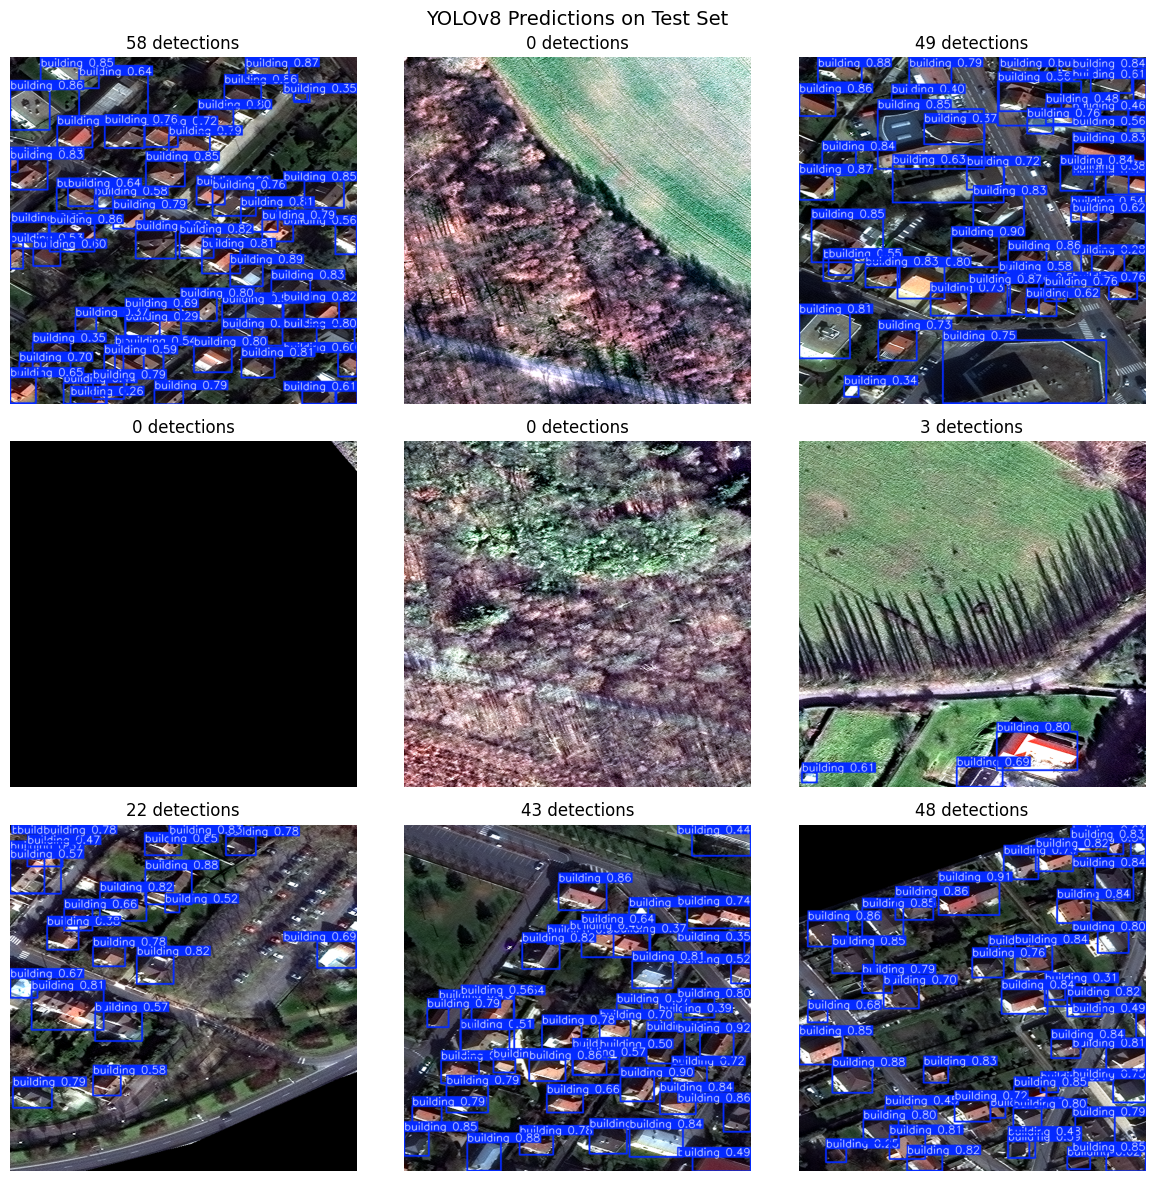

In [12]:
from ultralytics import YOLO
import glob, random, cv2, matplotlib.pyplot as plt
import numpy as np

# Load best model
model = YOLO('/content/runs/buildings_run1/weights/best.pt')

# Run on test set
test_imgs = glob.glob(f'{BASE}/images/test/*.png')
sample = random.sample(test_imgs, 9)

fig, axes = plt.subplots(3, 3, figsize=(12, 12))
for ax, img_path in zip(axes.flat, sample):
    results = model(img_path, verbose=False)[0]
    img = results.plot()  # draws boxes on image
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.set_title(f"{len(results.boxes)} detections")
    ax.axis('off')

plt.suptitle('YOLOv8 Predictions on Test Set', fontsize=14)
plt.tight_layout()
plt.show()

In [13]:
metrics = model.val(
    data=f'{BASE}/data.yaml',
    split='test',
    verbose=True
)

print(f"\n--- Test Set Results ---")
print(f"mAP50:    {metrics.box.map50:.4f}")
print(f"mAP50-95: {metrics.box.map:.4f}")
print(f"Precision: {metrics.box.mp:.4f}")
print(f"Recall:    {metrics.box.mr:.4f}")

Ultralytics 8.4.63 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3096.1±1640.3 MB/s, size: 941.9 KB)
val: Scanning /content/dataset/labels/test... 116 images, 48 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 116/116 125.1it/s 0.9s
val: New cache created: /content/dataset/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 1.0s/it 8.0s
                   all        116       1656      0.801      0.749      0.793       0.49
Speed: 11.5ms preprocess, 11.9ms inference, 0.0ms loss, 9.0ms postprocess per image
Results saved to /content/runs/detect/val

--- Test Set Results ---
mAP50:    0.7931
mAP50-95: 0.4900
Precision: 0.8012
Recall:    0.7495
